### Clase 02 — Del Insight a los Datos

#### Análisis descriptivo, diagnóstico y predictivo
##### Ciclo Magistral · Inteligencia de Datos: Análisis e IA Aplicada · 2026
##### Mara Destefanis · Mgter. Ciencia de Datos · Lic. Comunicación Social

## Modelo predictivo — Demanda futura de paltas por región

**¿Qué predice este modelo?**
El volumen semanal de paltas vendidas (en libras) por región, usando el historial
de ventas y variables de calendario como predictores.

**¿Qué algoritmo usamos y por qué?**
LightGBM (Light Gradient Boosting Machine) — un modelo de árboles de decisión
con boosting por gradiente. Lo elegimos porque:
- Maneja variables categóricas (región, tipo) de forma nativa
- Captura patrones no lineales y estacionalidad sin transformaciones complejas
- Es rápido, eficiente en memoria y robusto con datasets medianos
- No requiere escalar las variables

**¿Cómo aprende?**
El modelo recibe como input features de fecha (año, mes, semana, trimestre),
el historial reciente de ventas (lags y promedios móviles) y la región/tipo,
y aprende a asociar esas condiciones con el volumen observado.

**Estrategia:**
Un único modelo global entrenado con todas las regiones simultáneamente,
usando Region_Geo y Tipo como variables categóricas.

### 0 - Set up 

In [4]:
# ── NOTEBOOK: 03_predictivo.ipynb ─────────────────────────────────────────────
# Propósito : predecir TotalVolume semanal por región con LightGBM
# Estrategia: modelo global — todas las regiones en un solo modelo

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy  as np
from pathlib import Path

# Modelo
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics         import mean_absolute_error, mean_squared_error

# Visualización
import plotly.graph_objects as go
import plotly.express       as px
from plotly.subplots        import make_subplots
import plotly.io            as pio

# ── Paleta y template ─────────────────────────────────────────────────────────
PALETA = {
    "hueso":   "#F2EFE4",
    "oliva":   "#7C8C5E",
    "tierra":  "#A0785A",
    "musgo":   "#4F6347",
    "pizarra": "#5A6472",
    "crema":   "#D9D2C0",
    "ink":     "#2C2C2C",
}

COLORES_SEQ = [
    PALETA["oliva"], PALETA["tierra"],
    PALETA["pizarra"], PALETA["musgo"], PALETA["crema"],
]

TEMPLATE_PALTA = go.layout.Template(
    layout=go.Layout(
        font          = dict(family="Georgia, serif", color=PALETA["ink"], size=12),
        paper_bgcolor = "white",
        plot_bgcolor  = "white",
        title         = dict(font=dict(size=14, color=PALETA["ink"]), x=0.5, xanchor="center"),
        xaxis         = dict(showgrid=False, linecolor=PALETA["ink"], linewidth=0.7),
        yaxis         = dict(gridcolor=PALETA["crema"], gridwidth=0.5,
                             linecolor=PALETA["ink"], linewidth=0.7),
        legend        = dict(bgcolor="rgba(0,0,0,0)", borderwidth=0, font=dict(size=10)),
        colorway      = COLORES_SEQ,
    )
)
pio.templates["palta"] = TEMPLATE_PALTA
pio.templates.default  = "palta"

pd.set_option("display.float_format", "{:,.2f}".format)



In [ ]:
# ── Carga ─────────────────────────────────────────────────────────────────────
DATA_PATH = Path(r"C:\Users\ASUS\Documents\Teacher\Clases_Magistrales\palta_1.csv")

palta_1 = pd.read_csv(DATA_PATH, parse_dates=["Fecha"])

print(f"Dataset cargado : {palta_1.shape[0]:,} filas · {palta_1.shape[1]} columnas")
print(f"Período         : {palta_1['Fecha'].min().date()} → {palta_1['Fecha'].max().date()}")
print(f"Regiones        : {palta_1['Region_Geo'].nunique()}")
print("Setup listo — arrancamos con feature engineering.")

In [5]:
# ── Carga de datos ────────────────────────────────────────────────────────────
DATA_PATH = Path(r"C:\Users\ASUS\Documents\Teacher\Clases_Magistrales\sesion2_Delosdatos-al-insight\Datos\palta_1.csv")

palta_1 = pd.read_csv(DATA_PATH, parse_dates=["Fecha"])

print(f"Dataset cargado: {palta_1.shape[0]:,} filas · {palta_1.shape[1]} columnas")
print(f"Dataset cargado : {palta_1.shape[0]:,} filas · {palta_1.shape[1]} columnas")
print(f"Período         : {palta_1['Fecha'].min().date()} → {palta_1['Fecha'].max().date()}")
print(f"Regiones        : {palta_1['Region_Geo'].nunique()}")
print("Setup listo — arrancamos con feature engineering.")


Dataset cargado: 52,483 filas · 9 columnas
Dataset cargado : 52,483 filas · 9 columnas
Período         : 2015-01-04 → 2023-12-03
Regiones        : 15
Setup listo — arrancamos con feature engineering.


In [6]:
display(palta_1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52483 entries, 0 to 52482
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Fecha              52483 non-null  datetime64[ns]
 1   PrecioPromedio     52483 non-null  float64       
 2   TotalVolume        52483 non-null  float64       
 3   Palta_Normal       52483 non-null  float64       
 4   Palta_Grande       52483 non-null  float64       
 5   Palta_Extragrande  52483 non-null  float64       
 6   TotalBags          52483 non-null  float64       
 7   Tipo               52483 non-null  object        
 8   Region_Geo         52483 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 3.6+ MB


None

In [8]:
# Formato 

palta_1[['Tipo','Region_Geo']] =palta_1[['Tipo','Region_Geo']].astype('category')
palta_1['Fecha'] = pd.to_datetime(palta_1["Fecha"])

In [9]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────────────────
# Construimos los predictores a partir de Fecha, Region_Geo y Tipo

df = palta_1[["Fecha", "Region_Geo", "Tipo", "TotalVolume"]].copy()

# Ordenamos — crítico para que los lags no mezclen el futuro con el pasado
df = df.sort_values(["Region_Geo", "Tipo", "Fecha"]).reset_index(drop=True)

# ── Features de calendario ────────────────────────────────────────────────────
df["anio"]      = df["Fecha"].dt.year
df["mes"]       = df["Fecha"].dt.month
df["semana"]    = df["Fecha"].dt.isocalendar().week.astype(int)
df["trimestre"] = df["Fecha"].dt.quarter

# ── Lag features — volumen de semanas anteriores ──────────────────────────────
# Agrupamos por región+tipo para que los lags no crucen entre regiones
grp = df.groupby(["Region_Geo", "Tipo"])["TotalVolume"]

df["lag_1"]  = grp.shift(1)   # semana anterior
df["lag_4"]  = grp.shift(4)   # un mes atrás
df["lag_8"]  = grp.shift(8)   # dos meses atrás
df["lag_52"] = grp.shift(52)  # mismo período año anterior

# ── Rolling mean — promedio móvil ─────────────────────────────────────────────
df["roll_4"]  = grp.shift(1).transform(lambda x: x.rolling(4,  min_periods=1).mean())
df["roll_8"]  = grp.shift(1).transform(lambda x: x.rolling(8,  min_periods=1).mean())

# ── Categóricas ───────────────────────────────────────────────────────────────
df["Region_Geo"] = df["Region_Geo"].astype("category")
df["Tipo"]       = df["Tipo"].astype("category")

# Eliminamos filas con NaN en lags (primeras semanas de cada región)
df = df.dropna(subset=["lag_1", "lag_4", "lag_8"]).reset_index(drop=True)

print(f"Dataset con features: {df.shape[0]:,} filas · {df.shape[1]} columnas")
print(f"Features construidas : {[c for c in df.columns if c not in ['Fecha','TotalVolume']]}")

Dataset con features: 52,243 filas · 14 columnas
Features construidas : ['Region_Geo', 'Tipo', 'anio', 'mes', 'semana', 'trimestre', 'lag_1', 'lag_4', 'lag_8', 'lag_52', 'roll_4', 'roll_8']


In [10]:
# ── SPLIT TEMPORAL Y ENTRENAMIENTO ────────────────────────────────────────────
# Usamos split temporal — nunca aleatorio en series de tiempo
# Últimas 12 semanas como test, el resto como train

FEATURES = [
    "anio", "mes", "semana", "trimestre",
    "lag_1", "lag_4", "lag_8", "lag_52",
    "roll_4", "roll_8",
    "Region_Geo", "Tipo"
]
TARGET = "TotalVolume"

# Fecha de corte — últimas 12 semanas
fecha_corte = df["Fecha"].max() - pd.Timedelta(weeks=12)

train = df[df["Fecha"] <= fecha_corte]
test  = df[df["Fecha"] >  fecha_corte]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Train : {train.shape[0]:,} filas · hasta {train['Fecha'].max().date()}")
print(f"Test  : {test.shape[0]:,}  filas · desde {test['Fecha'].min().date()}")

# ── Entrenamiento ─────────────────────────────────────────────────────────────
params = {
    "objective":        "regression",
    "metric":           "mae",
    "learning_rate":    0.05,
    "num_leaves":       31,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "verbose":          -1,
}

modelo = lgb.LGBMRegressor(**params, n_estimators=500)
modelo.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],
    callbacks             = [lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(100)],
    categorical_feature   = ["Region_Geo", "Tipo"],
)

print(f"\nMejor iteración : {modelo.best_iteration_}")
print("Modelo entrenado — pasamos a evaluación.")

Train : 50,851 filas · hasta 2023-09-10
Test  : 1,392  filas · desde 2023-09-17
[100]	valid_0's l1: 189653
[200]	valid_0's l1: 169042
[300]	valid_0's l1: 159431
[400]	valid_0's l1: 155244
[500]	valid_0's l1: 150818

Mejor iteración : 500
Modelo entrenado — pasamos a evaluación.


El modelo convergió bien y el MAE bajó consistentemente de 189K a 150K libras en 500 iteraciones sin estancarse, lo que sugiere que podría seguir mejorando con más estimadores. Pero primero evaluamos para entender qué tan bueno es ese número en contexto.

In [11]:
# ── EVALUACIÓN ────────────────────────────────────────────────────────────────

y_pred = modelo.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mape = (np.abs((y_test - y_pred) / y_test.replace(0, np.nan)).mean()) * 100

print(f"MAE  : {mae:,.0f} lbs")
print(f"RMSE : {rmse:,.0f} lbs")
print(f"MAPE : {mape:.1f}%")
print(f"\nVolumen promedio en test : {y_test.mean():,.0f} lbs")
print(f"El modelo se equivoca en promedio un {mae/y_test.mean()*100:.1f}% del volumen típico")

MAE  : 150,818 lbs
RMSE : 423,646 lbs
MAPE : 127.2%

Volumen promedio en test : 524,603 lbs
El modelo se equivoca en promedio un 28.7% del volumen típico


Lo bueno:

MAE relativo al promedio: 28.7% — el modelo captura la magnitud general de la demanda
La bajada consistente del MAE en entrenamiento indica que aprendió patrones reales

La alerta — MAPE 127%:

El MAPE altísimo se explica por las regiones con volúmenes muy bajos (cerca de cero) — cuando el denominador es pequeño, cualquier error se dispara porcentualmente. Es el mismo problema que vimos en la distribución: Palta_Extragrande con mediana casi en cero. El MAPE no es confiable con este dataset por eso.
El RMSE vs MAE:

RMSE (423K) es casi 3x el MAE (150K) — indica que hay algunos errores muy grandes puntuales, probablemente en las regiones de alto volumen como California o Northeast.

Es un punto de partida. 

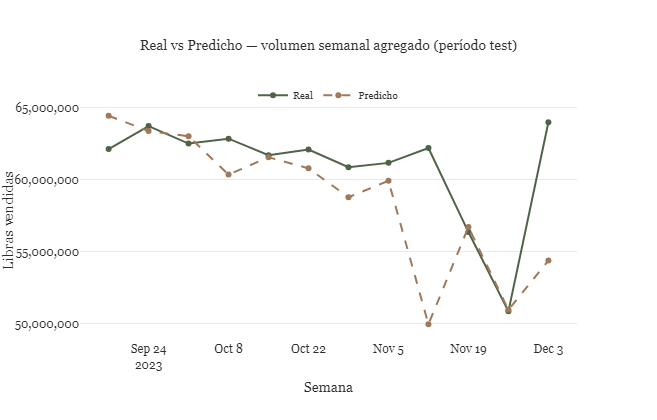

In [12]:
# ── GRÁFICO: Real vs Predicho ─────────────────────────────────────────────────

resultado = test[["Fecha", "Region_Geo", "Tipo", TARGET]].copy()
resultado["Predicho"] = y_pred

# Agregamos por fecha para ver tendencia nacional
comp = (
    resultado
    .groupby("Fecha")[["TotalVolume", "Predicho"]]
    .sum()
    .reset_index()
)

fig_eval = go.Figure()

fig_eval.add_trace(go.Scatter(
    x    = comp["Fecha"],
    y    = comp["TotalVolume"],
    name = "Real",
    mode = "lines+markers",
    line = dict(color=PALETA["musgo"], width=2),
    marker = dict(size=6),
))

fig_eval.add_trace(go.Scatter(
    x    = comp["Fecha"],
    y    = comp["Predicho"],
    name = "Predicho",
    mode = "lines+markers",
    line = dict(color=PALETA["tierra"], width=2, dash="dash"),
    marker = dict(size=6),
))

fig_eval.update_layout(
    title       = "Real vs Predicho — volumen semanal agregado (período test)",
    xaxis_title = "Semana",
    yaxis_title = "Libras vendidas",
    yaxis       = dict(tickformat=",.0f"),
    height      = 420,
    legend      = dict(orientation="h", y=1.08, x=0.5, xanchor="center"),
)

fig_eval.show()

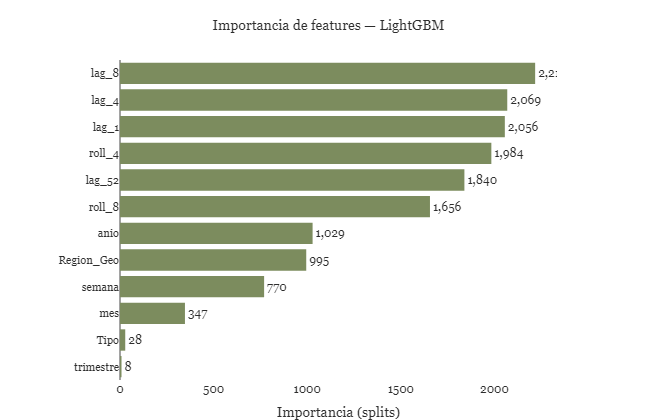

In [13]:
# ── GRÁFICO: Importancia de features ─────────────────────────────────────────

importancia = pd.DataFrame({
    "Feature":     FEATURES,
    "Importancia": modelo.feature_importances_,
}).sort_values("Importancia")

fig_imp = go.Figure()

fig_imp.add_trace(go.Bar(
    x            = importancia["Importancia"],
    y            = importancia["Feature"],
    orientation  = "h",
    marker_color = PALETA["oliva"],
    text         = importancia["Importancia"].apply(lambda x: f"{x:,.0f}"),
    textposition = "outside",
))

fig_imp.update_layout(
    title       = "Importancia de features — LightGBM",
    xaxis_title = "Importancia (splits)",
    yaxis_title = "",
    height      = 420,
    margin      = dict(l=120, r=100, t=60, b=40),
    yaxis       = dict(tickfont=dict(size=11)),
)

fig_imp.show()

## Conclusiones del modelo predictivo — LightGBM

### ¿Qué aprendió el modelo?
El mejor predictor de la demanda futura de paltas es la demanda pasada reciente.
Los lags (lag_1, lag_4, lag_8) y promedios móviles (roll_4, roll_8) dominan
la importancia de features, lo que confirma que el mercado de paltas tiene
inercia — lo que se vendió las últimas semanas es la mejor señal de lo que
se venderá la próxima.

### Métricas
| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| MAE | 150,818 lbs | Error promedio absoluto |
| RMSE | 423,646 lbs | Sensible a errores grandes puntuales |
| MAPE | 127.2% | No confiable — regiones con volumen cercano a cero distorsionan |
| Error relativo | 28.7% | El modelo se equivoca ~29% del volumen típico |

### Limitaciones del modelo actual
- El MAPE es poco confiable por regiones con volúmenes muy bajos (Palta_Extragrande)
- El RMSE alto indica errores puntuales grandes en regiones de alto volumen
- No se incorporaron variables externas (precio, estacionalidad climática, eventos)

### Próximos pasos para mejorar
1. **Aumentar n_estimators** — el MAE seguía bajando en iteración 500
2. **Agregar PrecioPromedio como feature** — precio y demanda están relacionados
3. **Modelar por tipo separado** — convencional y orgánico pueden tener dinámicas distintas
4. **Incorporar lag_52 con más peso** — la estacionalidad anual es relevante en este mercado
5. **Evaluar por región** — identificar en qué regiones el modelo falla más